In [2]:
!pip install biopython torch torch-geometric scipy numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.6 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

from Bio.PDB import PDBParser
from scipy.spatial.distance import pdist, squareform

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

In [4]:
def download_pdb(pdb_id):
    filename = f"{pdb_id}.pdb"
    if not os.path.exists(filename):
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        urllib.request.urlretrieve(url, filename)
    return filename


def load_protein(pdb_file):
    parser = PDBParser()
    structure = parser.get_structure("protein", pdb_file)

    coords = []
    seq = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if "CA" in residue:
                    coords.append(residue["CA"].get_coord())
                    seq.append(residue.get_resname())

    return np.array(coords), seq

In [5]:
def download_pdb(pdb_id):
    filename = f"{pdb_id}.pdb"
    if not os.path.exists(filename):
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        urllib.request.urlretrieve(url, filename)
    return filename


def load_protein(pdb_file):
    parser = PDBParser()
    structure = parser.get_structure("protein", pdb_file)

    coords = []
    seq = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if "CA" in residue:
                    coords.append(residue["CA"].get_coord())
                    seq.append(residue.get_resname())

    return np.array(coords), seq

In [6]:
def build_graph(features):

    N = len(features)
    edges = []
    k = 3

    for i in range(N):
        for j in range(max(0,i-k), min(N,i+k+1)):
            if i != j:
                edges.append([i,j])

    edge_index = torch.tensor(edges).t().contiguous()
    x = torch.tensor(features, dtype=torch.float)

    return Data(x=x, edge_index=edge_index)

In [15]:
amino_acids = [
"ALA","CYS","ASP","GLU","PHE","GLY","HIS",
"ILE","LYS","LEU","MET","ASN","PRO","GLN",
"ARG","SER","THR","VAL","TRP","TYR"
]

aa_to_idx = {aa:i for i,aa in enumerate(amino_acids)}

def encode_sequence(sequence):
    features = []

    for aa in sequence:
        vec = np.zeros(20)
        if aa in aa_to_idx:
            vec[aa_to_idx[aa]] = 1
        features.append(vec)

    return np.array(features)

In [16]:
dataset = []

for pdb_id in pdb_list:
    try:
        file = download_pdb(pdb_id)
        coords, seq = load_protein(file)

        # keep only medium-sized proteins
        if len(seq) < 30 or len(seq) > 150:
            print("Skipped (size):", pdb_id)
            continue

        print(pdb_id, "Length:", len(seq))  # DEBUG

        # TEMP: remove strict filtering
        if len(seq) < 20:
            continue

        dist_matrix = squareform(pdist(coords))

        contact_map = (dist_matrix <= 8).astype(int)

        for i in range(len(contact_map)):
            for j in range(len(contact_map)):
                if abs(i-j) < 6:
                    contact_map[i,j] = 0

        features = encode_sequence(seq)
        graph = build_graph(features)

        dataset.append((graph, torch.tensor(contact_map, dtype=torch.float)))

        print("Loaded:", pdb_id)

    except Exception as e:
        print("Skipped:", pdb_id, "| Error:", e)

print("Total proteins:", len(dataset))

1CRN Length: 46
Loaded: 1CRN
Skipped (size): 1A3N
2MCM Length: 113
Loaded: 2MCM
1UBQ Length: 76
Loaded: 1UBQ
1BTA Length: 89
Loaded: 1BTA


/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4891.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4934.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4977.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 5020.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 5063.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 5188.
  warnings.warn(
/usr/local/lib/python3.12/di

Skipped (size): 1L2Y
Skipped (size): 2PTL
1CAG Length: 88
Loaded: 1CAG
Skipped (size): 1GFL
1HHP Length: 99
Loaded: 1HHP
1MBA Length: 146
Loaded: 1MBA
1OAI Length: 68
Loaded: 1OAI


/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1039.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1043.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 1051.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1063.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1091.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 1117.
  warnings.warn(
/usr/local/lib/python3.12/di

Skipped (size): 1PLW
1R69 Length: 63
Loaded: 1R69
Total proteins: 9


In [17]:
class GNN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = SAGEConv(20,64)
        self.conv2 = SAGEConv(64,128)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self,x,edge_index):

        x = self.conv1(x,edge_index)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv2(x,edge_index)
        x = torch.relu(x)

        return x


def pairwise(x):

    N = x.shape[0]

    xi = x.unsqueeze(1).repeat(1,N,1)
    xj = x.unsqueeze(0).repeat(N,1,1)

    pair = torch.cat([xi,xj],dim=-1)

    idx = torch.arange(N)
    seq_dist = torch.abs(idx.unsqueeze(1)-idx.unsqueeze(0)).unsqueeze(-1)

    pair = torch.cat([pair, seq_dist.float()], dim=-1)

    return pair


class ContactPredictor(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.fc = torch.nn.Linear(257,1)

    def forward(self,pair):
        return self.fc(pair)


class ContactGNN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.gnn = GNN()
        self.pred = ContactPredictor()

    def forward(self,data):

        x = self.gnn(data.x,data.edge_index)
        pair = pairwise(x)
        out = self.pred(pair)

        return out.squeeze(-1)

In [21]:
model = ContactGNN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

pos_weight = torch.tensor(5.0)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

epochs = 200

for epoch in range(epochs):

    total_loss = 0

    for graph, target in dataset:

        optimizer.zero_grad()

        output = model(graph)

        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch, "Loss", total_loss)

Epoch 0 Loss 6.253002285957336
Epoch 1 Loss 6.003714561462402
Epoch 2 Loss 5.78711810708046
Epoch 3 Loss 5.58358359336853
Epoch 4 Loss 5.413957864046097
Epoch 5 Loss 5.250275552272797
Epoch 6 Loss 5.097899794578552
Epoch 7 Loss 4.964978724718094
Epoch 8 Loss 4.8794752061367035
Epoch 9 Loss 4.791638672351837
Epoch 10 Loss 4.729821354150772
Epoch 11 Loss 4.710338830947876
Epoch 12 Loss 4.657144367694855
Epoch 13 Loss 4.6340669095516205
Epoch 14 Loss 4.600958526134491
Epoch 15 Loss 4.591474950313568
Epoch 16 Loss 4.580615371465683
Epoch 17 Loss 4.5719165205955505
Epoch 18 Loss 4.563230097293854
Epoch 19 Loss 4.528552383184433
Epoch 20 Loss 4.550051897764206
Epoch 21 Loss 4.527450650930405
Epoch 22 Loss 4.5053887367248535
Epoch 23 Loss 4.492441326379776
Epoch 24 Loss 4.506475389003754
Epoch 25 Loss 4.48734125494957
Epoch 26 Loss 4.487988173961639
Epoch 27 Loss 4.473447948694229
Epoch 28 Loss 4.460228502750397
Epoch 29 Loss 4.478613913059235
Epoch 30 Loss 4.428622305393219
Epoch 31 Loss 4.4

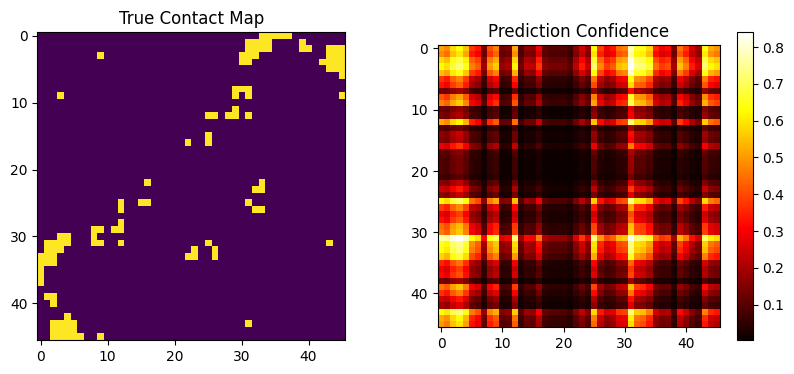

In [26]:
graph, target = dataset[0]

logits = model(graph)

pred = torch.sigmoid(logits)

L = pred.shape[0]
top_k = L // 5

flat = pred.flatten()
indices = torch.topk(flat, top_k).indices

pred_contact = torch.zeros_like(flat)
pred_contact[indices] = 1

pred_contact = pred_contact.view(L, L)

# enforce symmetry
pred_contact = (pred_contact + pred_contact.T) // 2

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(target)
plt.title("True Contact Map")

plt.subplot(1,2,2)
plt.imshow(pred.detach().numpy(), cmap="hot")
plt.title("Prediction Confidence")
plt.colorbar()
plt.show()

In [27]:
def accuracy(pred, target):
    pred = pred.flatten()
    target = target.flatten()
    return (pred == target).sum().item() / len(target)


def precision(pred, target):
    tp = ((pred == 1) & (target == 1)).sum().item()
    fp = ((pred == 1) & (target == 0)).sum().item()
    return tp / (tp + fp + 1e-8)


def recall(pred, target):
    tp = ((pred == 1) & (target == 1)).sum().item()
    fn = ((pred == 0) & (target == 1)).sum().item()
    return tp / (tp + fn + 1e-8)


def f1_score(pred, target):
    p = precision(pred, target)
    r = recall(pred, target)
    return 2 * (p * r) / (p + r + 1e-8)


def precision_at_L(pred_scores, target, L):
    pred_scores = pred_scores.flatten()
    target = target.flatten()
    topk = torch.topk(pred_scores, L//10).indices
    selected = target[topk]
    return selected.sum().item() / (len(selected) + 1e-8)

In [28]:
print("Accuracy:", accuracy(pred_contact, target))
print("Precision:", precision(pred_contact, target))
print("Recall:", recall(pred_contact, target))
print("F1 Score:", f1_score(pred_contact, target))
print("Precision@L/10:", precision_at_L(pred, target, len(target)))

Accuracy: 0.9465973534971645
Precision: 0.6666666659259258
Recall: 0.05172413792657551
F1 Score: 0.09599999864832003
Precision@L/10: 0.7499999981250001
